# Auto Encoders

Auto encoders are a type of neural network used for unsupervised learning. They consist of an encoder that compresses the input data into a lower-dimensional representation, and a decoder that reconstructs the original data from this compressed representation. The goal of an auto encoder is to learn a compact representation of the input data while minimizing the reconstruction error.

In [1]:
# remove the tf warnings
import os

from keras.src.callbacks import EarlyStopping

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer

In [3]:
!nvidia-smi

Sun May 17 10:46:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [9]:
import nltk
from nltk.corpus import gutenberg
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re

In [10]:
nltk.download('gutenberg')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

### 1. Load the raw text

In [5]:
from nltk.corpus import gutenberg
raw_text = gutenberg.raw('austen-emma.txt')

In [6]:
len(raw_text)

887071

### 2. Clean and tokenize

In [7]:
import re
text = re.sub(r'[^a-zA-Z\s]', '', raw_text).lower()
words = text.split()

### 3. Lemmatization and Stopword Removal


In [11]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

processed_words = [
    lemmatizer.lemmatize(word) for word in words
    if word not in stop_words and len(word) > 1
]
processed_text = " ".join(processed_words)

### 4. Keras Tokenization

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 5000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<UNK>")
tokenizer.fit_on_texts([processed_text])
sequences = tokenizer.texts_to_sequences([processed_text])[0]

word2idx = tokenizer.word_index
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"Total words in processed corpus: {len(sequences)}")
print(f"Vocabulary size capped at: {VOCAB_SIZE}")

Total words in processed corpus: 72868
Vocabulary size capped at: 5000


In [16]:
import numpy as np

WINDOW_SIZE = 2
X = []
Y = []

# Generate pairs: Target -> Context
for i in range(WINDOW_SIZE, len(sequences) - WINDOW_SIZE):
    target_word = sequences[i]

    # Context window bounds
    context_words = (
        sequences[i - WINDOW_SIZE : i] +
        sequences[i + 1 : i + WINDOW_SIZE + 1]
    )

    for context in context_words:
        X.append(target_word)
        Y.append(context)

X = np.array(X)
Y = np.array(Y)

print(f"Generated {len(X)} training pairs.")

Generated 291456 training pairs.


In [26]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten
from tensorflow.keras.layers import Input

EMBEDDING_DIM = 50

model = Sequential([
    # FIX: Explicit Input layer tells Keras the exact shape immediately
    Input(shape=(1,)),

    # Encoder bottleneck
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, name="encoder_embedding"),
    Flatten(),

    # Decoder reconstruction
    Dense(VOCAB_SIZE, activation='softmax', name="decoder_dense")
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 1, 50)          │       250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense (Dense)           │ (None, 5000)           │       255,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 505,000 (1.93 MB)

 Trainable params: 505,000 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0564 - loss: 6.8163 - val_accuracy: 0.0715 - val_loss: 6.9844
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0568 - loss: 6.7903 - val_accuracy: 0.0722 - val_loss: 6.9826
Epoch 3/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0571 - loss: 6.7621 - val_accuracy: 0.0710 - val_loss: 6.9828
Epoch 4/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0576 - loss: 6.7321 - val_accuracy: 0.0700 - val_loss: 6.9857
Epoch 5/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0582 - loss: 6.7007 - val_accuracy: 0.0684 - val_loss: 6.9881
Epoch 6/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0587 - loss: 6.6680 - val_accuracy: 0.0694 - val_loss: 6.9913
Epoch 7/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0593 - loss: 6.6345 - val_accuracy: 0.0682 - val_loss: 6.9942


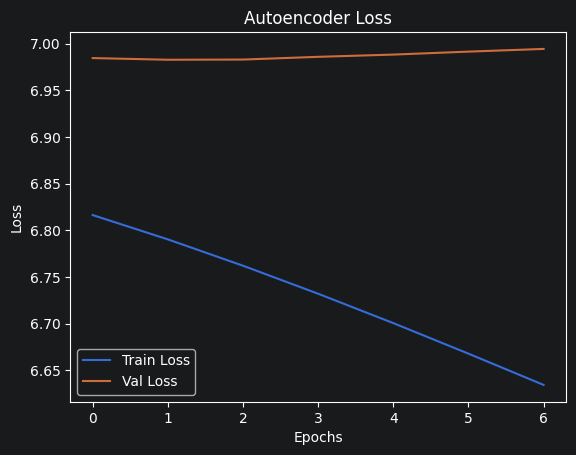

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 30
BATCH_SIZE = 1024

history = model.fit(
    X, Y,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1, # Keep an eye on overfitting
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)],
)

# Plot training curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

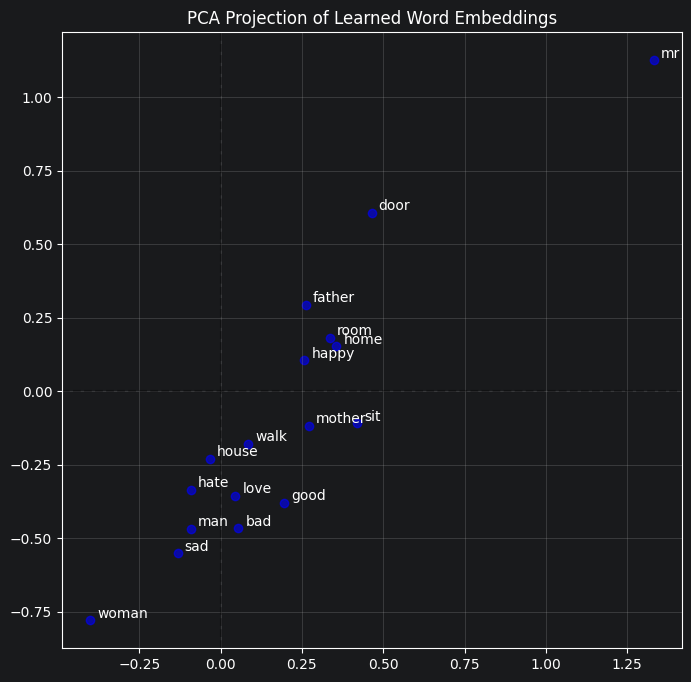

In [29]:
from sklearn.decomposition import PCA

# Extract the learned embeddings
embeddings = model.get_layer("encoder_embedding").get_weights()[0]

# Fit PCA to reduce 50 dimensions to 2 dimensions
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Define a cluster of specific words to plot (relationships should naturally emerge)
words_to_plot = [
    'man', 'woman', 'mr', 'mrs', 'father', 'mother',
    'good', 'bad', 'happy', 'sad', 'love', 'hate',
    'house', 'home', 'room', 'door', 'walk', 'sit'
]

plt.figure(figsize=(8, 8))

for word in words_to_plot:
    if word in word2idx and word2idx[word] < VOCAB_SIZE:
        idx = word2idx[word]
        x, y = reduced_embeddings[idx]

        plt.scatter(x, y, color='blue', alpha=0.6)
        plt.annotate(word, (x, y), xytext=(5, 2), textcoords='offset points', fontsize=10)

plt.title("PCA Projection of Learned Word Embeddings")
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.show()